In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [2]:
api = wandb.Api()

In [3]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s14/distill-layerwise/run1/distill-imagenet"

In [18]:
def read_data(
    teacher,
    student,
    dataset,
    policy,
    lambda_task,
    lambda_kd,
    arr_training_sizes,
    arr_contamination_levels,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": {"$in": arr_training_sizes}},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
            {"config.dataset": dataset}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["training_size", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        5,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="imagenet-resnet18-tv",
    student="resnet18compr2",
    dataset="imagenet-butterfly",
    policy="basis-identity:random--uncentered",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0],
    
    lambda_task=0.0,
    lambda_kd=1.0,
    
    verbose=True,
)

summary

we have 20 runs
df.shape: (4, 12)


training_size contamination_level   val_acc                 val_agreement  \
                                         mean       std count          mean   
0          0.10                   0  0.887333  0.007958     5      0.898667   
1          0.25                   0  0.924000  0.002789     5      0.936000   
2          0.50                   0  0.937333  0.007226     5      0.954667   
3          1.00                   0  0.947333  0.004944     5      0.958667   

                  val_agreement_on_teacher_correct                 teacher_acc  
        std count                             mean       std count        mean  
0  0.012605     5                         0.879333  0.009832     5    0.966667  
1  0.005963     5                         0.916667  0.004714     5    0.966667  
2  0.007674     5                         0.934000  0.008300     5    0.966667  
3  0.004472     5                         0.939333  0.004346     5    0.966667

In [6]:
def read_data_baseline(
    teacher,
    student,
    lambda_task,
    lambda_kd,
    training_size,
    arr_contamination_levels,
    verbose=False,
    
):
    raise NotImplementedError("to be run")
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP + "-baselinerun"},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": "basis-identity:random--uncentered"},
            {"config.training_size": training_size},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]

        assert run.config["lambda_layer"] is not None

        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["training_size", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        20,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

read_data_baseline(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    training_size=1.0,
    arr_contamination_levels=[0.0],
    lambda_task=0.0,
    lambda_kd=1.0
)

NotImplementedError: to be run

# Comparison on `training-size` and `contamination-level`

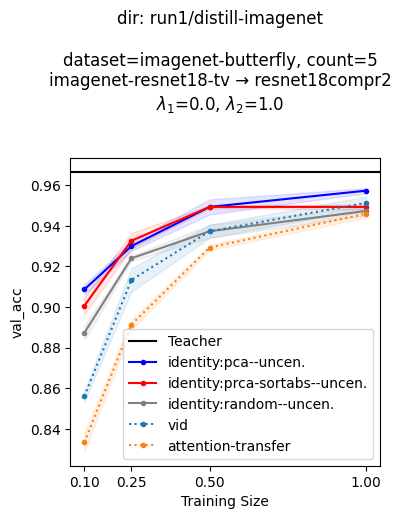

In [20]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    return policy \
        .replace("basis-identity", "identity") \
        .replace("uncentered", "uncen.")

    
    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner" or policy == "fitnetinvidbnrelu":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher, student, policies, 
    arr_training_sizes,
    show_legend=True,
    include_baseline=True
):
        
        
    dataset = "imagenet-butterfly"
    lambda_kd = 1.0
    lambda_task = 0.0

    
        

    col = "val_acc"
    
    ncols = 1
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])
    
    for pix, policy in enumerate(policies):

        
        df = read_data(
            teacher=teacher,
            student=student,
            dataset=dataset,
            policy=policy,

            lambda_task=lambda_task,
            lambda_kd=lambda_kd,

            arr_training_sizes=arr_training_sizes,
            arr_contamination_levels=[0],
            verbose=False
        )

        ticks = df["training_size"]

            
        # visualize baseline
        if pix == 0:

            plt.axhline(
                df["teacher_acc"].values[-1],
                ls="-",
                color="k",
                label="Teacher"
            )

            if include_baseline:
                df_baseline = read_data_baseline(
                    teacher=teacher,
                    student=student,

                    lambda_task=lambda_task,
                    lambda_kd=lambda_kd,

                    training_size=training_size,
                    arr_contamination_levels=arr_contamination_levels,
                )
                plt.plot(
                    ticks,
                    df_baseline[col]["mean"],
                    ls="--",
                    color="k",
                    label="Student (KD Only)"
                )

#                 plt.axhline(0.2, ls="--", color="lightgray")

        # here, we take the first value.
        # the query function already checks that the value is expected
        count = df[col]["count"].values[-1]

        mean = df[col]["mean"]
        stderr = df[col]["std"] / (count ** 0.5)

        plt.plot(
            ticks,
            mean,
            marker=".",
            label=alias(policy),
            ls=ls(policy),
            color=color(policy)
        )

        plt.fill_between(
            ticks,
            mean - stderr,
            mean + stderr,
            alpha=0.1,
            color=plt.gca().lines[-1].get_color()
        )

    plt.xlabel("Training Size")
    plt.xticks(ticks)
    plt.ylabel(col)

    plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"dataset={dataset}, count={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "imagenet-resnet18-tv",
    student="resnet18compr2",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    policies = [ 
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ][:5],
    include_baseline=False
) 

# Summary (to be written)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3 = \{0, 10^{-3}, 10^{-2}, \dots,  10^5\}$

*Aims:* 
- ... 

*Conclusion:*
- ... 


*Remark*: 
- Currently, the accuracy comes from the validation set. Preferbably, we repeat this again using a proper validation/test set.